# Structured Output
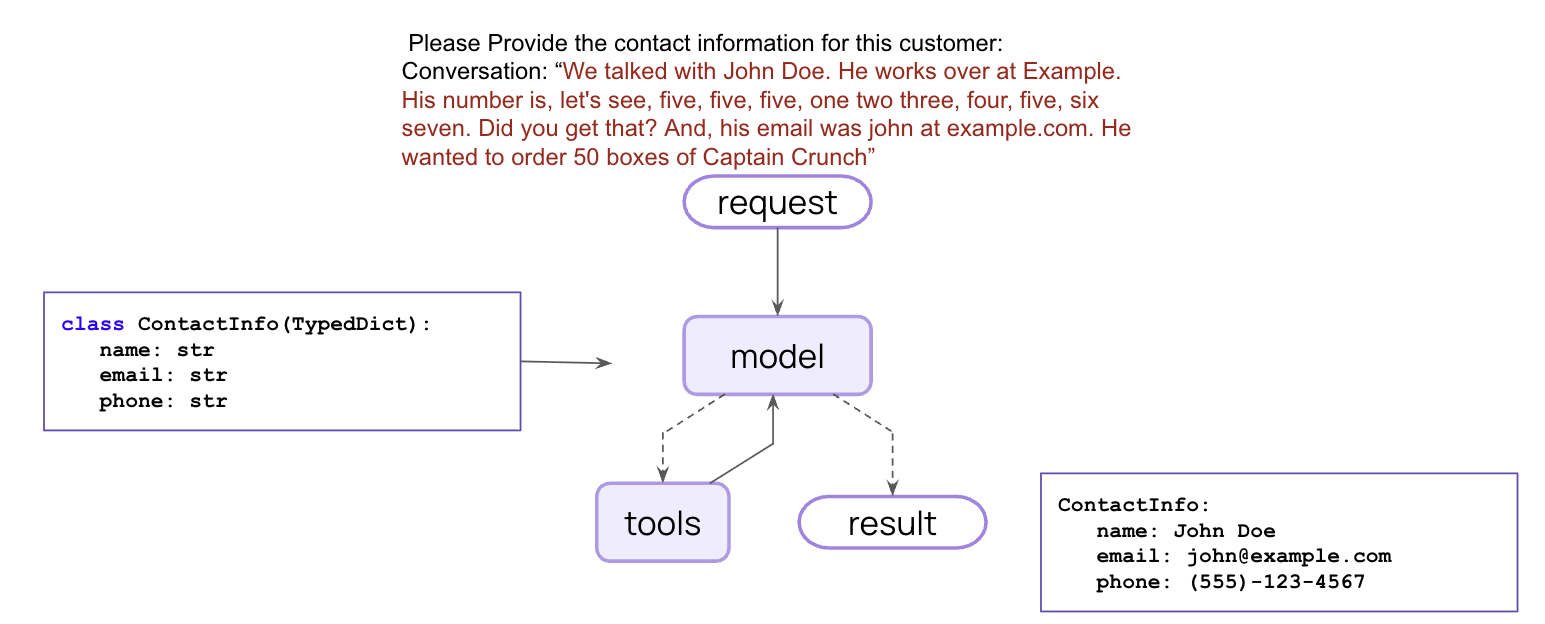


## Setup

Load and/or check for needed environmental variables

In [1]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0, http_client=http_client)

## Structured Output Example

In [3]:
from typing_extensions import TypedDict

from langchain.agents import create_agent


class ContactInfo(TypedDict):
    name: str
    email: str
    phone: str


agent = create_agent(model=llm, response_format=ContactInfo)

recorded_conversation = """We talked with John Doe. He works over at Example. His number is, let's see, 
five, five, five, one two three, four, five, six seven. Did you get that?
And, his email was john at example.com. He wanted to order 50 boxes of Captain Crunch."""

result = agent.invoke(
    {"messages": [{"role": "user", "content": recorded_conversation}]}
)

result["structured_response"]

{'name': 'John Doe', 'email': 'john@example.com', 'phone': '555-123-4567'}

#### Multiple data types are supported 

* pydantic `BaseModel`
* `TypedDict`
* `dataclasses`
* json schema (dict)

In [4]:
from langchain.agents import create_agent
from pydantic import BaseModel


class ContactInfo(BaseModel):
    name: str
    email: str
    phone: str


agent = create_agent(model=llm, response_format=ContactInfo)

recorded_conversation = """ We talked with John Doe. He works over at Example. His number is, let's see, 
five, five, five, one two three, four, five, six seven. Did you get that?
And, his email was john at example.com. He wanted to order 50 boxes of Captain Crunch."""

result = agent.invoke(
    {"messages": [{"role": "user", "content": recorded_conversation}]}
)

result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='555-123-4567')